In [1]:
#Install requirements
%pip install -r "../requirements.txt"

Note: you may need to restart the kernel to use updated packages.


In [2]:
#Import required libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.linear_model import LinearRegression
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix, 
    classification_report,
    precision_score,
    recall_score,
    f1_score,
    roc_curve,
    roc_auc_score,
    mean_squared_error,
    mean_absolute_error,
    r2_score,
    ConfusionMatrixDisplay)

import os
import scipy
from scipy.stats import pearsonr

In [4]:
#Import the data-feature matrices generated in Task 1

if not os.path.exists("../data/processed"):
    print("Processed Data Path does not exist. Expected in `../data/processed`. Run first data_exploration.ipynb")
    exit

#Load Training Data
X_train_metadata = pd.read_pickle('../data/processed/X_train_metadata.pkl')
X_train_cpg = pd.read_pickle('../data/processed/X_train_cpg.pkl')
X_train_final = pd.read_pickle('../data/processed/X_train_final.pkl')
y_train = pd.read_pickle('../data/processed/y_train.pkl')

#Load Validation Data
X_val_metadata = pd.read_pickle('../data/processed/X_val_metadata.pkl')
X_val_cpg = pd.read_pickle('../data/processed/X_val_cpg.pkl')
X_val_final = pd.read_pickle('../data/processed/X_val_final.pkl')
y_val = pd.read_pickle('../data/processed/y_val.pkl')

print('Data for training and validation set loaded successfully')


Data for training and validation set loaded successfully


In [18]:
#Train OLS for the feature matrices of the training set

#Metadata_Matrix
#Initialize and Fit
metadata_OLS = LinearRegression().fit(X_train_metadata, y_train)

#Get predictions using the validation set
y_pred_metadata = metadata_OLS.predict(X_val_metadata)

#Score
metadata_OLS_r2 = metadata_OLS.score(X_train_metadata, y_train)
print(f"Training R^2 for the Metadata features: {metadata_OLS_r2:.4f}")

Training R^2 for the Metadata features: 0.2209


In [19]:
#CpG Matrix
#Initialize and Fit
cpg_OLS = LinearRegression().fit(X_train_cpg, y_train)

#Get predictions using the validation set
y_pred_cpg = cpg_OLS.predict(X_val_cpg)

#Score
cpg_OLS_r2 = cpg_OLS.score(X_train_cpg, y_train)
print(f"Training R^2 for the CpG features: {cpg_OLS_r2:.4f}")

Training R^2 for the CpG features: 1.0000


In [20]:
#Combined_Matrix
#Initialize and Fit
combined_OLS = LinearRegression().fit(X_train_final, y_train)

#Get predictions using the validation set
y_pred_combined = combined_OLS.predict(X_val_final)

#Score
combined_OLS_r2 = combined_OLS.score(X_train_final, y_train)
print(f"Training R^2 for the Combined features: {combined_OLS_r2:.4f}")

Training R^2 for the Combined features: 1.0000


In [21]:
import os
import sys

#Add the src to the path
sys.path.append(os.path.abspath(os.path.join('..')))

In [22]:
#Bootstrap Resampling for validation

from src.functions import bootstrap_apply

#For the Metadata Features
bootstrap_metadata = bootstrap_apply(y_pred_metadata, y_val)
bootstrap_metadata_mean = bootstrap_metadata.mean()
bootstrap_metadata_95CI = round(bootstrap_metadata.quantile([0.025, 0.975]), 2)

print(f"The OLS Metadata Baseline Statistics")
print(bootstrap_metadata_mean)
print("\n 95% CI")
print(bootstrap_metadata_95CI)

The OLS Metadata Baseline Statistics
RMSE         11.823112
MAE           9.260137
R2            0.230310
Pearson_r     0.496823
dtype: float64

 95% CI
        RMSE    MAE    R2  Pearson_r
0.025   9.78   7.81  0.05       0.33
0.975  14.03  10.78  0.39       0.65


In [23]:
#For the CpG Features
bootstrap_cpg = bootstrap_apply(y_pred_cpg, y_val)
bootstrap_cpg_mean = bootstrap_cpg.mean()
bootstrap_cpg_95CI = round(bootstrap_cpg.quantile([0.025, 0.975]),2)

print(f"The OLS CpG Baseline Statistics")
print(bootstrap_cpg_mean)
print("\n 95% CI")
print(bootstrap_cpg_95CI)

The OLS CpG Baseline Statistics
RMSE         5.456697
MAE          4.073278
R2           0.832755
Pearson_r    0.920595
dtype: float64

 95% CI
       RMSE   MAE    R2  Pearson_r
0.025  4.34  3.42  0.74       0.88
0.975  6.76  4.85  0.90       0.95


In [24]:
#For the Combined Features
bootstrap_combined = bootstrap_apply(y_pred_combined, y_val)
bootstrap_combined_mean = bootstrap_combined.mean()
bootstrap_combined_95CI = round(bootstrap_combined.quantile([0.025, 0.975]),2)

print(f"The OLS Combined Baseline Statistics")
print(bootstrap_combined_mean)
print("\n 95% CI")
print(bootstrap_combined_95CI)

The OLS Combined Baseline Statistics
RMSE         5.429341
MAE          4.058774
R2           0.834492
Pearson_r    0.921153
dtype: float64

 95% CI
       RMSE   MAE    R2  Pearson_r
0.025  4.32  3.41  0.75       0.88
0.975  6.71  4.84  0.90       0.95


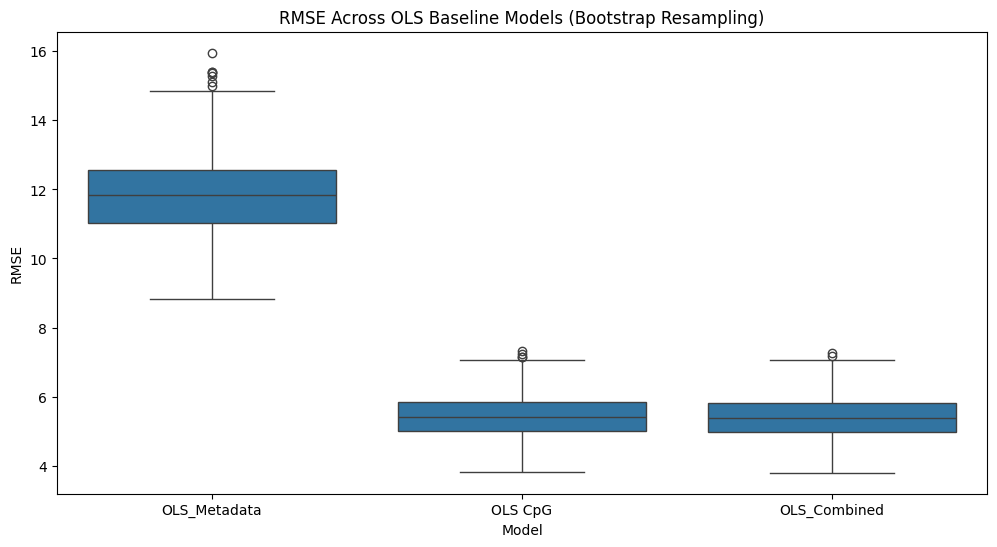

In [25]:
#Compare the 3 baseline models (RMSE, R2)
os.makedirs('../figures/Task2_Figures', exist_ok=True)

baseline_results = pd.concat([
    bootstrap_metadata.assign(Model='OLS_Metadata'),
    bootstrap_cpg.assign(Model='OLS CpG'),
    bootstrap_combined.assign(Model='OLS_Combined')])

#RMSE Boxplot for the baseline models 
plt.figure(figsize=(12,6))
sns.boxplot(data=baseline_results, x='Model', y='RMSE')
plt.title('RMSE Across OLS Baseline Models (Bootstrap Resampling)')
plt.savefig('../figures/Task2_Figures/RMSE_OLS_Baseline.png', dpi=300, bbox_inches='tight')
plt.show()

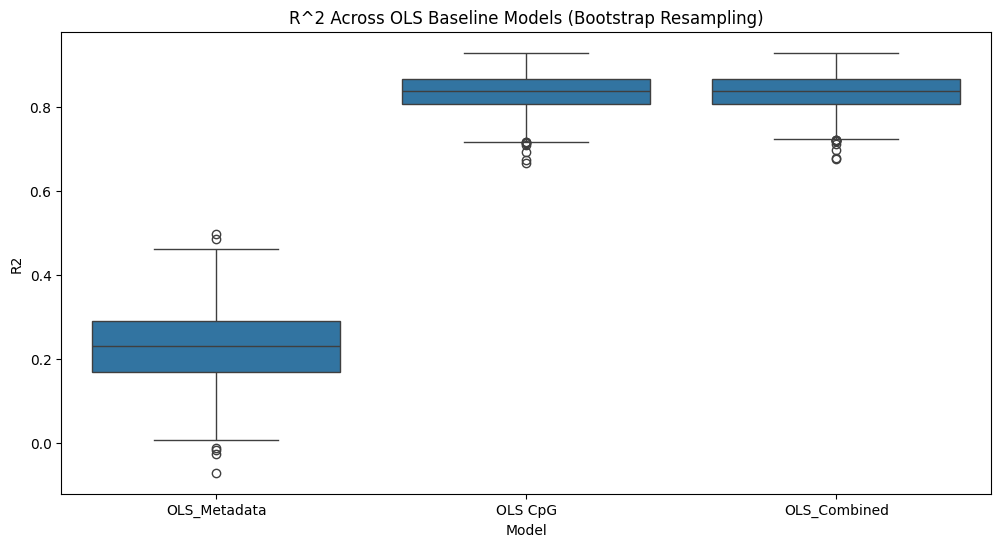

In [26]:
#R2 Boxplot for the baseline models 
plt.figure(figsize=(12,6))
sns.boxplot(data=baseline_results, x='Model', y='R2')
plt.title('R^2 Across OLS Baseline Models (Bootstrap Resampling)')
plt.savefig('../figures/Task2_Figures/R2_OLS_Baseline.png', dpi=300, bbox_inches='tight')
plt.show()

In [27]:
#Save OLS models 
import joblib

os.makedirs('../models/OLS_Baseline_Models', exist_ok=True)

joblib.dump(metadata_OLS, '../models/OLS_Baseline_Models/metadata_ols_baseline.joblib' )
joblib.dump(cpg_OLS, '../models/OLS_Baseline_Models/cpg_ols_baseline.joblib' )
joblib.dump(combined_OLS, '../models/OLS_Baseline_Models/combined_ols_baseline.joblib' )

['../models/OLS_Baseline_Models/combined_ols_baseline.joblib']

In [ ]:
#Save Metrics

metadata_stats = [
    round(bootstrap_metadata['RMSE'].mean(),2),
    f"[{bootstrap_metadata['RMSE'].quantile(0.025):.2f}, {bootstrap_metadata['RMSE'].quantile(0.975):.2f}]",
    round(bootstrap_metadata['MAE'].mean(),2),
    round(bootstrap_metadata['R2'].mean(),2),
    round(bootstrap_metadata['Pearson_r'].mean(),2)
]

cpg_stats = [
    round(bootstrap_cpg['RMSE'].mean(),2),
    f"[{bootstrap_cpg['RMSE'].quantile(0.025):.2f}, {bootstrap_cpg['RMSE'].quantile(0.975):.2f}]",
    round(bootstrap_cpg['MAE'].mean(),2),
    round(bootstrap_cpg['R2'].mean(),2),
    round(bootstrap_cpg['Pearson_r'].mean(),2)
]

combined_stats = [
    round(bootstrap_combined['RMSE'].mean(),2),
    f"[{bootstrap_combined['RMSE'].quantile(0.025):.2f}, {bootstrap_combined['RMSE'].quantile(0.975):.2f}]",
    round(bootstrap_combined['MAE'].mean(),2),
    round(bootstrap_combined['R2'].mean(),2),
    round(bootstrap_combined['Pearson_r'].mean(),2)
]

OLS_Metrics = {
    'Metric' : ['RMSE Mean', '95% CI (RMSE)', 'MAE', 'R^2', 'Pearson r'],
    'OLS_Metadata' : metadata_stats,
    'OLS_CpG' : cpg_stats,
    'OLS_Combined' : combined_stats
}

table_statistics = pd.DataFrame(OLS_Metrics).round(3)

os.makedirs('../data/Baseline', exist_ok=True)
table_statistics.to_csv('../data/baseline/task2_ols_baseline_metrics.csv', index=False)

In [29]:
#Train 3 algorithms on the CpG only set with default hyperparameters
from sklearn.linear_model import ElasticNet, BayesianRidge
from sklearn.svm import SVR

#ElasticNet Algorithm
#Initialize and Fit the model on CpG training set
cpg_elasticnet = ElasticNet(random_state=42, l1_ratio=0.5).fit(X_train_cpg, y_train) #default hyperparameters

#Predict on validation set
cpg_elasticnet_pred = cpg_elasticnet.predict(X_val_cpg)


In [30]:
#SVR
#Initialize and Fit the model
cpg_svr = SVR(kernel='rbf', C=1.0).fit(X_train_cpg, y_train) #default hyperparameters

#Predict on validation set
cpg_svr_pred = cpg_svr.predict(X_val_cpg)

In [31]:
#BayesianRidge
#Initialize and Fit the model
cpg_bayesianridge = BayesianRidge().fit(X_train_cpg, y_train) #default hyperparameters

#Predict on validation set
cpg_bayesianridge_pred = cpg_bayesianridge.predict(X_val_cpg)

In [32]:
#After the training of the above algorithms, we proceed with the evaluation on the validation set using the same bootstrap method as for the OLS models
#Bootstrap

from src.functions import bootstrap_apply

#Dictionary with the 3 different models
cpg_models_pred = {
    'ElasticNet' : cpg_elasticnet_pred,
    'SVR' : cpg_svr_pred,
    'BayesianRidge' : cpg_bayesianridge_pred}

#Initialize an empty dictionary, in which the bootstrap metrics will be saved
cpg_models_stats = {}

for model_name, y_pred in cpg_models_pred.items():
    #Perform the bootstrap function
    bootstrap_df = bootstrap_apply(y_pred, y_val, n_resamples=1000, seed=42)
    #Store the bootstraq results in the dictionary
    cpg_models_stats[model_name] = bootstrap_df

    print(f"Bootstrap pipeline completed for the model: {model_name}")


Bootstrap pipeline completed for the model: ElasticNet
Bootstrap pipeline completed for the model: SVR
Bootstrap pipeline completed for the model: BayesianRidge


In [33]:
#Save the cpg models
import joblib

os.makedirs('../models/CpG_Baseline_Models', exist_ok=True)

joblib.dump(cpg_elasticnet, '../models/CpG_Baseline_Models/cpg_elasticnet_baseline.joblib' )
joblib.dump(cpg_svr, '../models/CpG_Baseline_Models/cpg_svr_baseline.joblib' )
joblib.dump(cpg_bayesianridge, '../models/CpG_Baseline_Models/cpg_bayesianridge_baseline.joblib' )

['../models/CpG_Baseline_Models/cpg_bayesianridge_baseline.joblib']

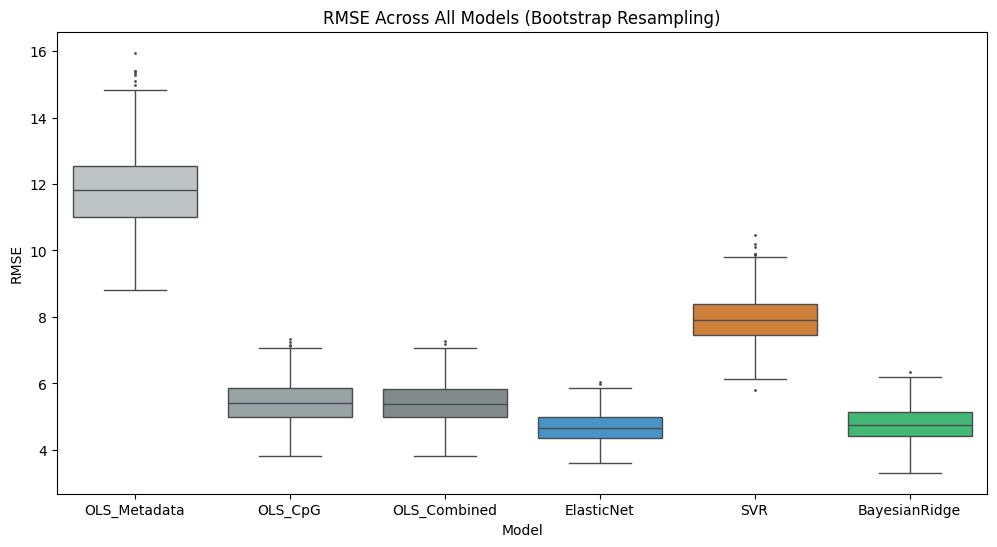

In [36]:
#Compare all the models (RMSE, R2)

os.makedirs('../figures/Task2_Figures', exist_ok=True)

all_models_results = pd.concat([
    bootstrap_metadata.assign(Model='OLS_Metadata'),
    bootstrap_cpg.assign(Model='OLS_CpG'),
    bootstrap_combined.assign(Model='OLS_Combined'),
    cpg_models_stats['ElasticNet'].assign(Model='ElasticNet'),
    cpg_models_stats['SVR'].assign(Model='SVR'),
    cpg_models_stats['BayesianRidge'].assign(Model='BayesianRidge')])

colors = {
    'OLS_Metadata': '#bdc3c7', 'OLS_CpG': '#95a5a6', 'OLS_Combined': '#7f8c8d', 
    'ElasticNet': '#3498db', 'SVR': '#e67e22', 'BayesianRidge': '#2ecc71' 
}

#RMSE Boxplot for all the models 
plt.figure(figsize=(12,6))
sns.boxplot(data=all_models_results, x='Model', y='RMSE', palette=colors, fliersize=1)
plt.title('RMSE Across All Models (Bootstrap Resampling)')
plt.ylabel('RMSE')
plt.savefig('../figures/Task2_Figures/RMSE_all_models_comparison.png', dpi=300, bbox_inches='tight')
plt.show()

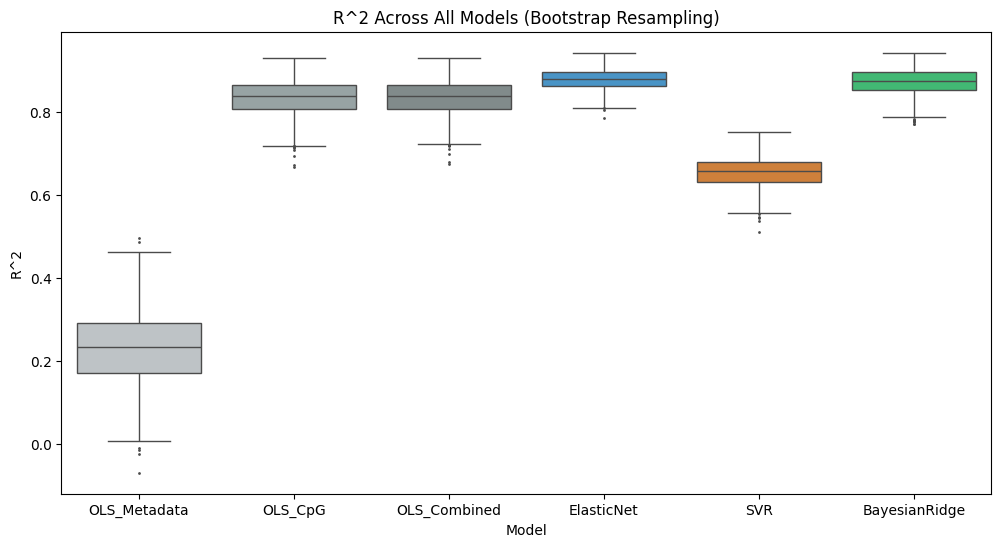

In [37]:
#R2 Boxplot for all the models 
plt.figure(figsize=(12,6))
sns.boxplot(data=all_models_results, x='Model', y='R2', palette=colors, fliersize=1)
plt.title('R^2 Across All Models (Bootstrap Resampling)')
plt.ylabel('R^2')
plt.savefig('../figures/Task2_Figures/R2_all_models_comparison.png', dpi=300, bbox_inches='tight')
plt.show()

In [ ]:
#Save Metrics from the cpg Models

elasticnet_stats = [
    round(cpg_models_stats['ElasticNet']['RMSE'].mean(),2),
    f"[{cpg_models_stats['ElasticNet']['RMSE'].quantile(0.025):.2f}, {cpg_models_stats['ElasticNet']['RMSE'].quantile(0.975):.2f}]",
    round(cpg_models_stats['ElasticNet']['MAE'].mean(),2),
    round(cpg_models_stats['ElasticNet']['R2'].mean(),2),
    round(cpg_models_stats['ElasticNet']['Pearson_r'].mean(),2)
]

svr_stats = [
    round(cpg_models_stats['SVR']['RMSE'].mean(),2),
    f"[{cpg_models_stats['SVR']['RMSE'].quantile(0.025):.2f}, {cpg_models_stats['SVR']['RMSE'].quantile(0.975):.2f}]",
    round(cpg_models_stats['SVR']['MAE'].mean(),2),
    round(cpg_models_stats['SVR']['R2'].mean(),2),
    round(cpg_models_stats['SVR']['Pearson_r'].mean(),2)
]

bayesianridge_stats = [
    round(cpg_models_stats['BayesianRidge']['RMSE'].mean(),2),
    f"[{cpg_models_stats['BayesianRidge']['RMSE'].quantile(0.025):.2f}, {cpg_models_stats['BayesianRidge']['RMSE'].quantile(0.975):.2f}]",
    round(cpg_models_stats['BayesianRidge']['MAE'].mean(),2),
    round(cpg_models_stats['BayesianRidge']['R2'].mean(),2),
    round(cpg_models_stats['BayesianRidge']['Pearson_r'].mean(),2)
]

Models_Metrics = {
    'Metric' : ['RMSE Mean', '95% CI (RMSE)', 'MAE', 'R^2', 'Pearson r'],
    'ElasticNet' : elasticnet_stats,
    'SVR' : svr_stats,
    'BayesianRidge' : bayesianridge_stats
}

models_table_statistics = pd.DataFrame(Models_Metrics).round(3)

os.makedirs('../data/Baseline', exist_ok=True)
models_table_statistics.to_csv('../data/baseline/task2_cpg_models_metrics.csv', index=False)